# Increase DINOv3 features resolution using padding 

In [1]:
import torch
from PIL import Image
import matplotlib.pyplot as plt 
from transformers import AutoModel

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Model loading

In [ ]:
# Model loading
pretrained_model_name = "facebook/dinov3-vitl16-pretrain-sat493m"
model = AutoModel.from_pretrained(
    pretrained_model_name, 
    device_map="auto", 
)
patch_size = model.config.patch_size

### Data

In [2]:
from torchvision.transforms import v2, Pad

def make_transform(resize_size: int = 1024):
    to_tensor = v2.ToImage()
    resize = v2.Resize((resize_size, resize_size), antialias=True)
    to_float = v2.ToDtype(torch.float32, scale=True)
    normalize = v2.Normalize(
        mean=(0.430, 0.411, 0.296),
        std=(0.213, 0.156, 0.143),
    )
    return v2.Compose([to_tensor, resize, to_float, normalize])

torch.Size([1, 3, 1024, 1024])


(np.float64(-0.5), np.float64(1023.5), np.float64(1022.5), np.float64(-0.5))

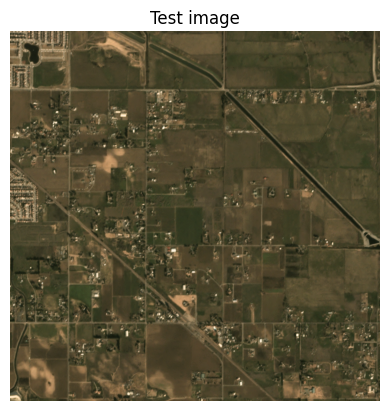

In [ ]:
img = Image.open("test_image.tif").convert('RGB')
# We transform the image to convert it to a model's input
input_image = make_transform(1024)(img).unsqueeze(0) # (1, 3, 1024, 1024)

plt.figure()
plt.title("Test image")
plt.imshow(img)
plt.axis('off')

### Shifted images to increase by 2 the resolution

In [16]:
padding_size = 8 # Shifted patches intersect at the middle of non-shifted patches

padding = Pad(padding_size)
padded_img = padding(img)

input_padded_img = make_transform(1024+2*padding_size)(padded_img).unsqueeze(0) # (1, 3, 1040, 1040)

### Extract multi-view features

In [ ]:
def extract_dinov3_features(model, input_tensor, normalize:bool=False):
    """Make an inference of the model return the features"""
    with torch.inference_mode():
        outputs = model(input_tensor.to(model.device))
        last_hidden_states = outputs.last_hidden_state
    patch_features_flat = last_hidden_states[:, 1 + model.config.num_register_tokens:, :]
    if normalize:
        patch_features_flat = patch_features_flat/(torch.norm(patch_features_flat, dim=-1, keepdim=True)+1e-5)
    return patch_features_flat

In [ ]:
# Extract the features of the two views
img_size = input_image.shape[2]
extracted_features = extract_dinov3_features(model, input_image, False).reshape(1, img_size//patch_size, img_size//patch_size, -1) # (1, 64, 64, 1024)
extracted_features_shifted = extract_dinov3_features(model, input_padded_img, False).reshape(1, img_size//patch_size + 1, img_size//patch_size + 1, -1) # (1, 65, 65, 1024)

extracted_features = extracted_features.permute(0, 3, 1, 2)
extracted_features_shifted = extracted_features_shifted.permute(0, 3, 1, 2)

# Duplicate the features via nearest neighbor interpolation to match the final resolution
features_up = torch.nn.functional.interpolate(extracted_features, scale_factor=2, mode='nearest')
features_up_shifted = torch.nn.functional.interpolate(extracted_features_shifted, scale_factor=2, mode='nearest')

# Take only the center features of the padded version
features_up_shifted = features_up_shifted[:, :, 1:-1, 1:-1]

# Gather the features to perform the average pixel-wise
all_features = torch.cat((features_up, features_up_shifted), dim=0).permute(0, 2, 3, 1) # (2, 128, 128, 1024)
features_up = all_features.mean(dim=0, keepdim=True)
features_flat_up = features_up.flatten(1, 2)

## PCA between features

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, whiten=True)
normalized_features = features_flat_up / torch.norm(features_flat_up, dim=-1, keepdim=True)
pca.fit(normalized_features[0].detach().cpu())

In [ ]:
# apply the PCA, and then reshape
projected_image = torch.from_numpy(pca.transform(normalized_features[0].cpu().numpy())).view(128, 128, 3)

# multiply by 2.0 and pass through a sigmoid to get vibrant colors 
projected_image = torch.nn.functional.sigmoid(projected_image.mul(2.0)).permute(2, 0, 1)

# upsample image to its original shape
upsampled_image = v2.functional.resize(projected_image, size=img.size)

fig, ax = plt.subplots(1, 3, figsize=(30,10))
ax[0].imshow(projected_image.permute(1, 2, 0))
ax[0].set_title("PCA features projection")
ax[0].axis('off')
ax[1].imshow(upsampled_image.permute(1, 2, 0))
ax[1].set_title("Upsampled PCA")
ax[1].axis('off')
ax[2].imshow(img)
ax[2].set_title("Input image")
ax[2].axis('off')
plt.show()